###  all imports 

In [1]:
# imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
from PIL import Image
import io
import cairosvg
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim


project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

import src.pc.data_gen.data_generator as dgen
import src.pc.data_gen.test_data_generator as tgen
from src.pc.plot_gen.multi_cat import MultiCatPCPGenerator
from src.pc.plot_gen.single_cat import SingleCatPCPGenerator
from src.pc.plot_gen.axes_crop import CroppingProcessor
from src.pc.plot_gen.category_separation import CategorySeparator
from src.pc.data_gen.real_dist_info import extract_distributions_from_excel, extract_dist_plots_from_excel

from src.pc.data_gen.custom_dataset_unet import CustomDatasetUnetSD
from src.pc.models.unet import UNetSD
from src.pc.run_epoch_unet import train_epoch_unet_womo, validate_epoch_unet_womo
# import custom_dataset_unet as cus
from show_image import show_images_from_folder, plot_crop_lines1

# real world distrubution information file 

excel_path = "real_world_dis_info.xlsx"
real_dist = "real_world_dis_info_rgb.xlsx"
real_test_data_path = os.path.join(project_root, "data/raw_synthetic/real_inspired_data")

#synthetic csvs
raw_data_path = os.path.join(project_root, "data/raw_synthetic/training/data_example")
n_csv_files = 10
csv_seed = 767  


#synthetic plots multi categories  and groud truth with individual categories 
plot_paths = os.path.join(project_root, "data/synthetic_plots/training/plots")
svg_plot_paths = os.path.join(project_root, "data/synthetic_plots/training/svgs")
plots_nticks = os.path.join(project_root, "data/synthetic_plots/training/plots_nt")
plots_gt_cat_dir = os.path.join(project_root, "data/synthetic_plots/training/plots_gt_cat")
plots_cat_ntl_dir = os.path.join(project_root, "data/synthetic_plots/training/plots_gt_cat_ntl")
n_plots =10

# synthetic plots with crops and ground truth crops 
cropping_plots_no_ticks= os.path.join(project_root,"data/synthetic_plots/training/crops_ntl")
cropping_plots= os.path.join(project_root,"data/synthetic_plots/training/crops")
cropping_plots_cat= os.path.join(project_root,"data/synthetic_plots/training/crops_gt_cat")
cropping_plots_cat_ntl= os.path.join(project_root,"data/synthetic_plots/training/crops_gt_cat_ntl")

# synthetic plots with category separated after cropping
cat_sep= os.path.join(project_root,"data/synthetic_plots/training/cat_sep")


#unet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vis_dir = os.path.join(project_root, "visualizations")

### test_set distriubtion generation using real world distriubtion information 


In [5]:
axes_dist, cat_dist, rows_dist = extract_distributions_from_excel(real_dist)

dgen.generate_synthetic_datasets_from_distributions(
    directory_path=raw_data_path,
    k=n_csv_files,  # or 5000
    axes_distribution=axes_dist,
    categories_distribution=cat_dist,
    rows_distribution=rows_dist,
    seed=csv_seed  # for reproducibility
)

[✓] Generated 15 datasets using real-world distributions.
[✓] Annotations saved to: out_comb/csvs/annotations.json


### Generate plots and annotations jsons from csvs 

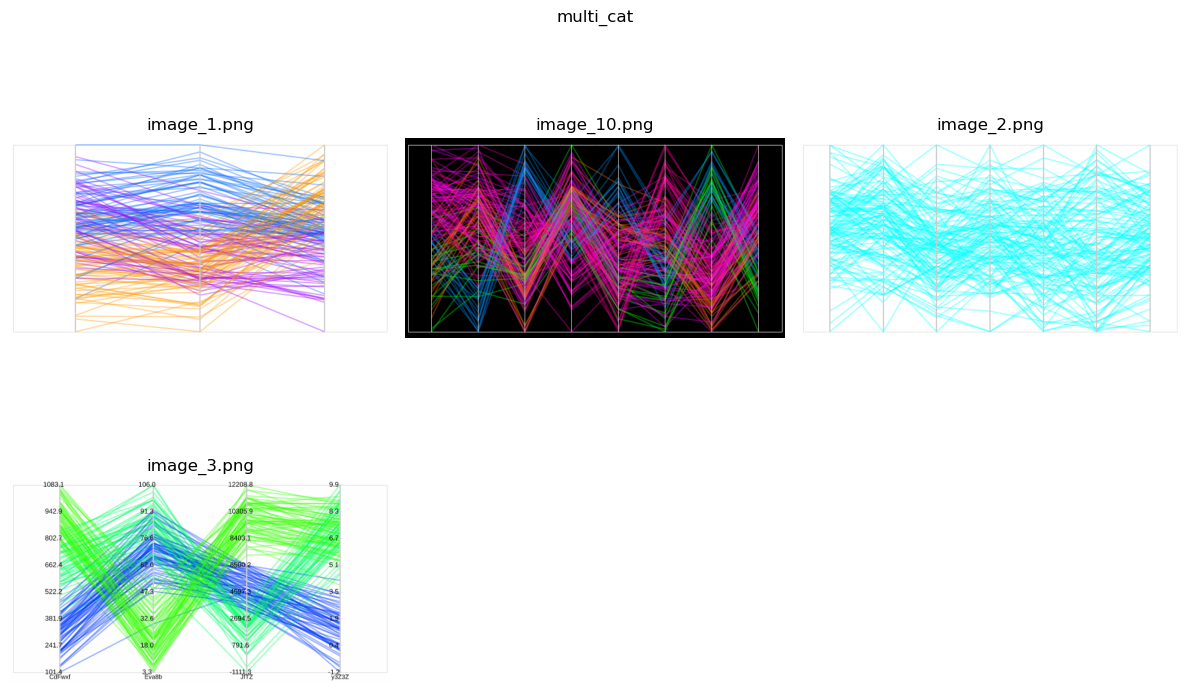

In [2]:
bg_dist, grid_dist,ticks_dist = extract_dist_plots_from_excel(real_dist)
# print(bg_dist, grid_dist,ticks_dist)  56666
plotter = MultiCatPCPGenerator(seed=45345) # 45345 # 56666
plotter.generate_batch(
    input_dir=raw_data_path,
    output_dir=plot_paths,
    svg_dir=svg_plot_paths,
    num_files=n_plots,
    background_distribution=bg_dist,
    grid_distribution=grid_dist,
    ticks_labels_distribution=ticks_dist, 
    no_ticks_output_dir=plots_nticks,
    per_cat_dir =plots_cat_dir,
    per_cat_ntl_dir =plots_cat_ntl_dir
        
)

show_images_from_folder(plot_paths, title="multi_cat")

### cropping 

In [ ]:
cp = CroppingProcessor()
#cropping of the plots
cp.create_crops(plot_paths, cropping_plots)
# perform cropping when the plots do not have ticks and labels
cp.create_crops(plots_nticks, cropping_plots_no_ticks)
# cropping of indidual category
cp.create_crops(plots_gt_cat_dir, cropping_plots_cat)
# cropping of indidual category without any ticks and labels
cp.create_crops(plots_cat_ntl_dir,cropping_plots_cat_ntl)

show_images_from_folder(cropping_plots_cat_ntl, title="crops")

In [ ]:
# plot_crop_lines1(
#     json_file='out_comb/plots_1/image_5.json',
#     filename="image_5_crop_2.png",
#     image_path='out_comb/cropping_plots_no_ticks_1/image_5_crop_2.png',
#     show_points= True,
#     show_lines = True
# )

# plot_crop_category_lines(
#     json_file='out_comb/plot_1/image_3.json',
#     filename="image_3_6ayE_crop_2.png",
#     image_path='out_comb/cropping_plots_pn_1/image_3_6ayE_crop_2.png'
# )





### Color histogram detection

In [ ]:
# Load the new image
import numpy as np
import cv2
from scipy.signal import find_peaks

# # Convert image to HSV
# img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

# # Extract H (Hue) channel only
# hue_channel = img_hsv[:,:,0].flatten()
# sat_channel = img_hsv[:,:,1].flatten()
# val_channel = img_hsv[:,:,2].flatten()

# # Mask out very low saturation pixels (grays/whites)
# mask = sat_channel > 50
# hue_filtered = hue_channel[mask]

# # Build histogram of Hue values (0-179 in OpenCV HSV)
# hist, bins = np.histogram(hue_filtered, bins=180, range=(0,180))

# # Find peaks in histogram
# peaks, _ = find_peaks(hist, height=np.max(hist)*0.1, distance=10)  # threshold = 10% of max

# # Convert peak hues back to RGB
# dominant_colors_hsv = [(int(h), 200, 200) for h in peaks]  # use fixed S,V for vivid color display
# dominant_colors_rgb = [cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0] 
#                        for hsv in dominant_colors_hsv]

# # Plot histogram and peaks
# plt.figure(figsize=(10,4))
# plt.plot(hist, label="Hue Histogram")
# plt.plot(peaks, hist[peaks], "rx", label="Detected Peaks")
# plt.title("Hue Histogram with Peaks")
# plt.xlabel("Hue Value (0-179)")
# plt.ylabel("Frequency")
# plt.legend()
# plt.show()

# dominant_colors_rgb

img2 = Image.open(image_over).convert("RGB")
img2_np = np.array(img2)

# Convert to HSV
img2_hsv = cv2.cvtColor(img2_np, cv2.COLOR_RGB2HSV)

# Extract channels
hue2 = img2_hsv[:,:,0].flatten()
sat2 = img2_hsv[:,:,1].flatten()

# Mask low saturation pixels (remove background/white)
mask2 = sat2 > 50
hue2_filtered = hue2[mask2]

# Histogram of hue
hist2, bins2 = np.histogram(hue2_filtered, bins=180, range=(0,180))

# Find peaks
peaks2, _ = find_peaks(hist2, height=np.max(hist2)*0.1, distance=10)

# Convert peaks to RGB colors
dominant_colors_hsv2 = [(int(h), 200, 200) for h in peaks2]
dominant_colors_rgb2 = [cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0] 
                        for hsv in dominant_colors_hsv2]

# Plot histogram with peaks
plt.figure(figsize=(10,4))
plt.plot(hist2, label="Hue Histogram")
plt.plot(peaks2, hist2[peaks2], "rx", label="Detected Peaks")
plt.title("Hue Histogram with Peaks (New Image)")
plt.xlabel("Hue Value (0-179)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(dominant_colors_rgb2)

import cv2
import numpy as np
from PIL import Image
from scipy.signal import find_peaks

def extract_dominant_colors(image_path, sat_thresh=50, peak_prominence=0.1, distance=10):
    """
    Extract dominant colors (HSV, RGB, HEX) from an image using histogram peaks.

    Args:
        image_path (str): Path to the image file
        sat_thresh (int): Minimum saturation to keep (default=50, removes gray/white)
        peak_prominence (float): Fraction of max histogram height to consider as peak
        distance (int): Minimum distance between peaks in hue values

    Returns:
        dominant_colors (list of dict): List of dominant colors with HSV, RGB, HEX
    """
    # Load and convert to HSV
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    # Extract channels
    hue = img_hsv[:,:,0].flatten()
    sat = img_hsv[:,:,1].flatten()

    # Mask low saturation (ignore background/white/gray)
    mask = sat > sat_thresh
    hue_filtered = hue[mask]

    # Histogram of Hue
    hist, bins = np.histogram(hue_filtered, bins=180, range=(0,180))

    # Find peaks
    peaks, _ = find_peaks(hist, height=np.max(hist)*peak_prominence, distance=distance)

    dominant_colors = []
    for h in peaks:
        hsv = (int(h), 200, 200)  # vivid S,V for visualization
        rgb = cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0].tolist()
        hex_code = '#%02x%02x%02x' % tuple(rgb)

        dominant_colors.append({
            "HSV": hsv,
            "RGB": tuple(rgb),
            "HEX": hex_code
        })

    return dominant_colors


colors = extract_dominant_colors(image_over)
for c in colors:
    print(c)





### Category separation from crops 

In [2]:
sep = CategorySeparator()
# sep.process_single_image_enhanced(
#     "out_comb/cropping_plots_no_ticks/image_4_crop_2.png",
#     "out_comb/plots/image_4.json",
#     "out_comb/cat_sep"
# )


sep.process_batch(
    cropping_plots,
    plot_paths,  # where jsons are present
    cat_sep,
    method="hist_enhanced"
)


Saved batch results in out_comb/cat_sep_1


### unet denoising 

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])

# Create dataset
dataset = CustomDatasetUnetSD(
    input_dir="out_comb/cat_sep_1",
    ground_truth_dir="out_comb/cropping_plots_pc_1",
    transform=transform,
    hsv_tolerance=0.15,
    remove_background=True   # turn background white if not white
)

# Wrap in DataLoader
dataloader_train = DataLoader(dataset, batch_size=2, shuffle=True)

# Iterate through batches
for input_imgs, gt_imgs in dataloader_train:
    print("Input shape:", input_imgs.shape)
    print("GT shape:", gt_imgs.shape)
    break


this is the file name  image_4_crop_4_xcjz.png
this is the file name  image_9_crop_2_a1VdPJ3.png
Input shape: torch.Size([2, 3, 224, 224])
GT shape: torch.Size([2, 3, 224, 224])


In [3]:
model = UNetSD(in_channels=3, out_channels=3).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_epoch_unet_womo(model, dataloader_train, criterion,
                                               optimizer, device)

this is the file name  image_8_crop_5_UT50.png
this is the file name  image_10_crop_5_Y1aYTFR.png


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.17 GiB. GPU 

In [ ]:
dataset = cus.CustomHSVMatchingDatasetSDMask(
    input_json = "dataset/training_data/data04_color_thres/line_with_sepimg.json", #cls_line_json_path 
    ground_truth_json= "dataset/training_data/data04_gt_plots_crops/gt_line_color.json",
    input_dir="dataset/training_data/data04_cluster_thres",
    ground_truth_dir="dataset/training_data/data04_gt_plots_crops",
    mask_dir="dataset/training_data/data04_gt_plots_crops_masks",
    transform=transform,
    hsv_tolerance=0.1  # Adjust as needed
)

In [ ]:
# unet inference 


tester = UNetTester(config, test_config)

# Run just one test (color)
tester.run(
    input_dir=test_config.m_color_sep_plots,
    output_dir=test_config.m_color_denoised_plots,
    description="Multi-color separation"
)

In [4]:
import numpy as np

# Load the NPZ file
file_path = "image_1_crop_1_cat_1_0_label.npz"

try:
    with np.load(file_path) as data:
        # Print the keys found in the archive
        print(f"Keys found in the NPZ file: {list(data.keys())}")
        
        for key in data.keys():
            arr = data[key]
            print("-" * 20)
            print(f"Key: {key}")
            print(f"Shape: {arr.shape}")
            print(f"Data Type: {arr.dtype}")
            
            # Check for non-zero values by summing
            print(f"Sum of all pixel values: {np.sum(arr)}")
            
            # If the data type is integer or boolean, check for values other than 0 and 1
            if arr.dtype in [np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64]:
                unique_values = np.unique(arr)
                print(f"Unique values in the array: {unique_values}")
            
            print("-" * 20)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Keys found in the NPZ file: ['mask']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
--------------------
Key: mask
Shape: (128, 128)
Data Type: uint8
Sum of all pixel values: 2283
Unique values in the array: [0 1]
--------------------
